## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

## |  Trabajo Semanal N°3




&emsp;&emsp;&emsp; Para el siguente trabajo semanal se observará un fenómeno que en los trabajos pasados no se dió debido a las condiciones en las que
se daban las señales a analizar en dichos casos. Hablamos de lo que se conoce como **Leakeage** o **Derramamiento espectral**, el cual se produce cuando se intenta muestrear una señal con una frecuencia $f_0$ , cuyo valor se encuentra entre un *bin* y su consecutivo, es decir que está por fuera de los múltiplos de la resolución espectral ($Δf$)

&nbsp;
&emsp;&emsp;&emsp; Vamos a determinar los parámetros a utilizar. El más importante será el factor $k_0$, el cual me define la cantidad de períodos que entran en la N cantidad de muestras, o básicamente el Bin en el que estoy. Además tomaremos el parámetro $Ps$ como facotr determinante para la potencia de la señal, la cual tiene varianza unitaria. Lo demás parámetros se mantendrán iguales a las TS anteriores, e iremos variando este nuevo factor $k_0$.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

N=1000
Ps = 1
fs = 1000
nn = np.arange(N)
k= N/4
ff= k* (fs/N)
vmax =np.sqrt(2*Ps)

### | Construcción de las señales y cálculo de potencias
&emsp;&emsp;&emsp; Vamos a ir variando el factor de $k$ de esta señal y ver qué ocurre para cada caso, además, en particular vamos a calcular la potencia de cada *PSD* verificando que cumpla la energía unitaria que planteamos al principio.

#### | Señal con $k = \frac{N}{4}$

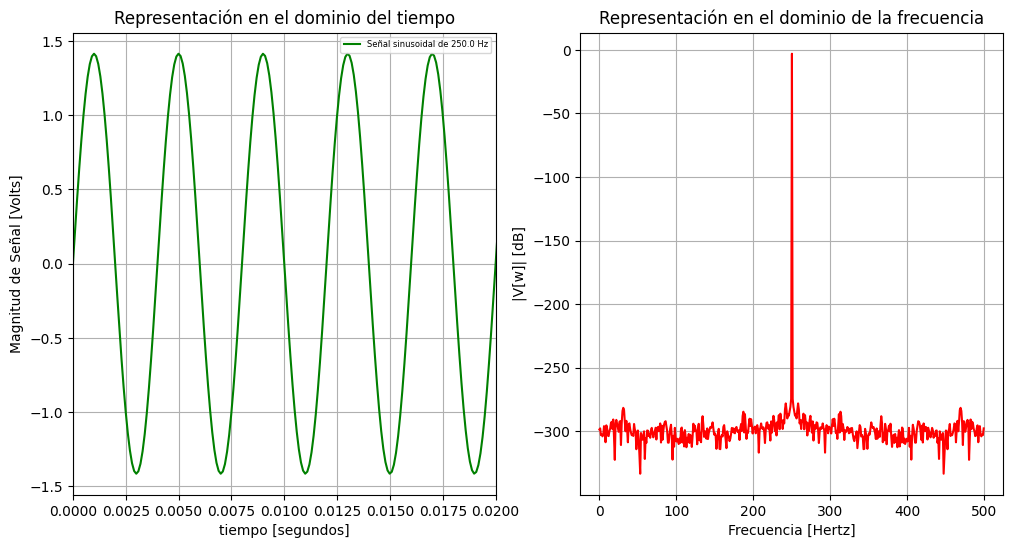

Potencia con la formula temporal:  1.0000000000000002 Watt
Potencia con la formula frecuencial:  1.0000000000000002 Watt


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Parte Temporal
tt = np.arange(0, N) / fs
xx = vmax * np.sin(2*np.pi*ff*tt)

#Hago una t fina para que se vea mejor el gráfico temporal
tt_fina = np.linspace(0, tt[-1], 10000)
xx_fina = vmax * np.sin(2*np.pi*ff*tt_fina)

ax1.plot(tt_fina, xx_fina, label=f"Señal sinusoidal de {ff} Hz",color='green')
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)
ax1.set_xlim(0, 5*(N/fs)/(k*fs/N))  # muestra 5 períodos
ax1.legend(loc="upper right", fontsize=6) 

# Parte Frecuencial
fftxxC = fft(xx)
fftxx = fft(xx)[:N//2]
fftxx_abs = np.abs(fftxx) / N
freq = fftfreq(N, 1/fs)[:N//2]

ax2.plot(freq, 20*np.log10(fftxx_abs),color='red')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel("|V[w]| [dB]")
ax2.grid(True)

plt.show()

PotTiempo = np.sum(np.abs(xx)**2) / N
PotFrecuencia = np.sum(np.abs(fftxxC)**2) / N**2 #Es N cuadrado ya que para frecuencia se ttoma 1/N y luego hay que normalizar por 1/N nuevamente 

print("Potencia con la formula temporal: ",PotTiempo,"Watt")
print("Potencia con la formula frecuencial: ",PotFrecuencia,"Watt")


&emsp;&emsp;&emsp; Este primer ejemplo es típico, donde tenemos una frecuencia que es múltiplo de la resolución espectral. Observamos en el apartado de frecuencial que tenemos una única componente que acumula toda la energía teóricamente, aunque como bien sebemos debido al error computacional existente, hay energía con niveles de magnitud muy bajos, que representan prácticamente nada de la energía total. Vemos también el cálculo de la potencia que, como era de esperarse, nos termina dando un valor de $1 Watt$.

#### | Señal con $k = \frac{N}{4} + 0.25$

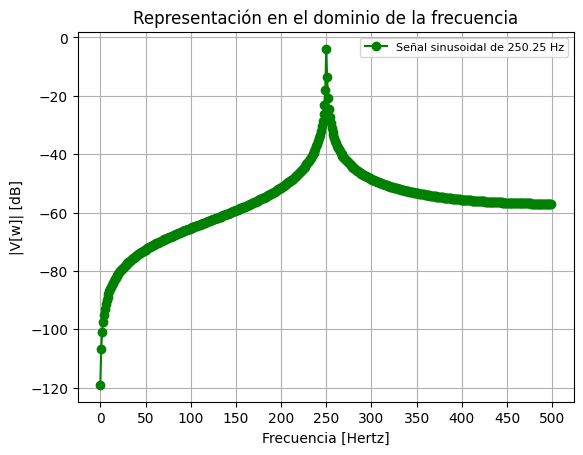

Potencia con la formula temporal:  0.9989999999999998 Watt
Potencia con la formula frecuencial:  0.9989999999999996 Watt


In [67]:
# Parte Temporal
k= (N/4) + 0.25
ff= k* (fs/N)

tt = np.arange(0, N) / fs
xx = vmax * np.sin(2*np.pi*ff*tt)

# Parte Frecuencial
fftxxC = fft(xx)
fftxx = fft(xx)[:N//2]
fftxx_abs = np.abs(fftxx) / N
freq = fftfreq(N, 1/fs)[:N//2]

plt.plot(freq, 20*np.log10(fftxx_abs), label=f"Señal sinusoidal de {ff} Hz",color='green', marker="o")
plt.title("Representación en el dominio de la frecuencia")
plt.xlabel("Frecuencia [Hertz]")
plt.ylabel("|V[w]| [dB]")
plt.xticks(np.arange(0, max(freq)+50, 50))  
plt.grid(True)
plt.legend(loc="upper right", fontsize=8) 

plt.show()

PotTiempo = np.sum(np.abs(xx)**2) / N
PotFrecuencia = np.sum(np.abs(fftxxC)**2) / N**2 #Es N cuadrado ya que para frecuencia se ttoma 1/N y luego hay que normalizar por 1/N nuevamente 

print("Potencia con la formula temporal: ",PotTiempo,"Watt")
print("Potencia con la formula frecuencial: ",PotFrecuencia,"Watt")

#### | Señal con $k = \frac{N}{4} + 0.5$

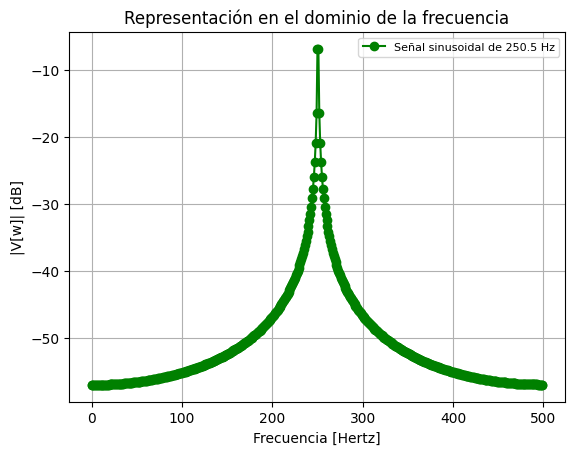

Potencia con la formula temporal:  1.0000000000000004 Watt
Potencia con la formula frecuencial:  1.0000000000000004 Watt


In [54]:
# Parte Temporal
k= (N/4) + 0.5
ff= k* (fs/N)

tt = np.arange(0, N) / fs
xx = vmax * np.sin(2*np.pi*ff*tt)

#Hago una t fina para que se vea mejor el gráfico temporal
tt_fina = np.linspace(0, tt[-1], 10000)
xx_fina = vmax * np.sin(2*np.pi*ff*tt_fina)



# Parte Frecuencial
fftxxC = fft(xx)
fftxx = fft(xx)[:N//2]
fftxx_abs = np.abs(fftxx) / N
freq = fftfreq(N, 1/fs)[:N//2]

plt.plot(freq, 20*np.log10(fftxx_abs), label=f"Señal sinusoidal de {ff} Hz",color='green', marker="o")
plt.title("Representación en el dominio de la frecuencia")
plt.xlabel("Frecuencia [Hertz]")
plt.ylabel("|V[w]| [dB]")
plt.grid(True)
plt.legend(loc="upper right", fontsize=8) 

plt.show()

PotTiempo = np.sum(np.abs(xx)**2) / N
PotFrecuencia = np.sum(np.abs(fftxxC)**2) / N**2 #Es N cuadrado ya que para frecuencia se ttoma 1/N y luego hay que normalizar por 1/N nuevamente 

print("Potencia con la formula temporal: ",PotTiempo,"Watt")
print("Potencia con la formula frecuencial: ",PotFrecuencia,"Watt")